# R4 — Rapid inference

Test accuracy as a function of frame position within each gas presentation.

Each ~20 s presentation contains ~16–19 data frames. We train classifiers on
all training frames (using every frame independently) and then measure how
accuracy evolves across the ordered positions inside each **test** presentation.

In [11]:
import numpy as np
from sklearn import metrics
import pickle, os
from math import comb
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tools import load

## Helpers (same expansion as `run_classification_136_train_test.py`)

In [12]:
def backward_diff_array(y, h, n):
    coeffs = np.array([(-1)**k * comb(n, k) for k in range(n + 1)])
    raw = np.convolve(y, coeffs, mode='valid') / h**n
    return np.concatenate([np.zeros(n), raw])


def expand_with_derivatives(data, h, max_order):
    if max_order == 0:
        return data.copy()
    derivs = [np.apply_along_axis(lambda c: backward_diff_array(c, h, o),
                                  axis=0, arr=data)
              for o in range(1, max_order + 1)]
    return np.hstack([data] + derivs)


n_sensors = 8
all_ordered_pairs = [(i, j) for i in range(n_sensors)
                     for j in range(n_sensors) if i != j]  # 56 pairs

def make_ratios(data, pairs, n):
    return np.column_stack([data[:, i] / (data[:, j] + 1e-8) for i, j in pairs[:n]])

def make_diffs(data, pairs, n):
    return np.column_stack([data[:, i] - data[:, j] for i, j in pairs[:n]])

def build_136(sensor_data, h):
    x_d12 = expand_with_derivatives(sensor_data, h, 2)
    r56 = make_ratios(sensor_data, all_ordered_pairs, 56)
    d56 = make_diffs(sensor_data, all_ordered_pairs, 56)
    return np.hstack([x_d12, r56, d56])

In [13]:
def make_frame_labels(times_sec, sequence, sequence_sec):
    """Assign a 1-indexed class label to every frame (0 = unlabelled gap)."""
    labels = np.zeros_like(times_sec)
    for i in range(len(sequence_sec)):
        try:
            flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
        except IndexError:
            flag = (times_sec > sequence_sec[i])
        labels[flag] = int(sequence[i][1])
    return labels


def get_presentation_blocks(times_sec, sequence, sequence_sec):
    """
    Return list of (label_0based, frame_indices) for each presentation.
    Only labelled presentations (label > 0) are included.
    """
    blocks = []
    for i in range(len(sequence_sec)):
        try:
            flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
        except IndexError:
            flag = (times_sec > sequence_sec[i])
        idxs = np.where(flag)[0]
        lab = int(sequence[i][1])
        if lab > 0 and len(idxs) > 0:
            blocks.append((lab - 1, idxs))
    return blocks


def accuracy_by_position(preds_1idx, labels_1idx, blocks, max_pos=19):
    """
    Compute accuracy at each frame position within presentations.

    Parameters
    ----------
    preds_1idx  : 1-D array, 1-indexed predicted class for every frame
    labels_1idx : 1-D array, 1-indexed ground-truth (0 = gap)
    blocks      : list of (label_0based, frame_indices)
    max_pos     : maximum number of positions to consider (0-indexed < max_pos)

    Returns
    -------
    positions, accuracy, counts  (all 1-D arrays)
    """
    correct = defaultdict(int)
    total   = defaultdict(int)
    for lab_0, idxs in blocks:
        lab_1 = lab_0 + 1
        for pos, idx in enumerate(idxs):
            if pos >= max_pos:
                break
            total[pos] += 1
            correct[pos] += int(preds_1idx[idx] == lab_1)
    positions = np.array(sorted(total.keys()))
    acc = np.array([correct[p] / total[p] for p in positions])
    counts = np.array([total[p] for p in positions])
    return positions, acc, counts

## 1. Single gases (`1_600_20`) — sequence-based split at 450

In [14]:
# --- Parameters (from gridsearch) ---
n_hd   = 10_000
p_hd   = 0.025
d      = 0.5
p      = 0.01
k      = int(d * n_hd)       # 5000
n_runs = 10

rng = np.random.default_rng(42)

# --- Load & expand ---
sd_s, seq_s, ts_s, ss_s = load('1_600_20', reduced=True)
h_s = np.median(np.diff(ts_s))
x_dense_s = build_136(sd_s, h_s)
n_dense_s = x_dense_s.shape[1]

n_out_s = 3
n_train_seq = 450

# Training labels (only first 450 sequences)
train_labels_s = np.zeros_like(ts_s)
for i in range(min(n_train_seq, len(ss_s))):
    try:
        flag = (ts_s > ss_s[i]) & (ts_s < ss_s[i + 1])
    except IndexError:
        flag = (ts_s > ss_s[i])
    train_labels_s[flag] = int(seq_s[i][1])

idx_last_train_s = np.where(train_labels_s != 0)[0][-1]

# Full frame labels (for test evaluation)
frame_labels_s = make_frame_labels(ts_s, seq_s, ss_s)

# Train/test time boundary
train_time_end_s = ss_s[n_train_seq] if n_train_seq < len(ss_s) else ts_s[-1] + 1
labeled_s = frame_labels_s > 0
test_mask_s = labeled_s & (ts_s >= train_time_end_s)

# Test presentation blocks
all_blocks_s = get_presentation_blocks(ts_s, seq_s, ss_s)
test_blocks_s = all_blocks_s[n_train_seq:]

print(f"Single gases: {n_dense_s} features, k={k}")
print(f"Train presentations: {n_train_seq}, Test presentations: {len(test_blocks_s)}")
print(f"Frames per test presentation: "
      f"min={min(len(b[1]) for b in test_blocks_s)}, "
      f"max={max(len(b[1]) for b in test_blocks_s)}, "
      f"median={np.median([len(b[1]) for b in test_blocks_s]):.0f}")

Single gases: 136 features, k=5000
Train presentations: 450, Test presentations: 150
Frames per test presentation: min=18, max=20, median=19


In [15]:
pkl_single = 'data/R4_single.pkl'

if os.path.exists(pkl_single):
    with open(pkl_single, 'rb') as f:
        saved = pickle.load(f)
    all_acc_s_test  = saved['test']
    all_acc_s_train = saved['train']
    pos_s = saved['pos']
    print(f"Loaded from {pkl_single}")
else:
    # --- 10 runs: expand & sparsify + Hebbian readout (single gases) ---
    all_blocks_s = get_presentation_blocks(ts_s, seq_s, ss_s)
    train_blocks_s = all_blocks_s[:n_train_seq]
    test_blocks_s  = all_blocks_s[n_train_seq:]

    all_acc_s_test  = []
    all_acc_s_train = []

    for run in range(n_runs):
        # Random HD projection
        W_hd = np.random.binomial(n=1, p=p_hd, size=(n_hd, n_dense_s))
        x_hd = x_dense_s @ W_hd.T

        # Top-k sparsification
        ranks = np.argsort(np.argsort(-x_hd, axis=1), axis=1)
        z_hd = np.where(ranks < k, 1., 0.)

        # Hebbian readout (train on first n_train_seq sequences)
        W_out = np.zeros((n_out_s, n_hd))
        for i, row in enumerate(z_hd[:idx_last_train_s]):
            if train_labels_s[i] != 0:
                active_idx = np.flatnonzero(row)
                to_flip = active_idx[rng.random(active_idx.size) < p]
                W_out[int(train_labels_s[i]) - 1, to_flip] = 1. / k

        # Frame-based inference
        z_out = z_hd @ W_out.T
        frame_preds = np.argmax(z_out, axis=1) + 1  # 1-indexed

        # Overall test accuracy
        test_acc = metrics.accuracy_score(frame_labels_s[test_mask_s], frame_preds[test_mask_s])

        # Per-position accuracy (train & test)
        pos, acc_te, _ = accuracy_by_position(frame_preds, frame_labels_s, test_blocks_s)
        _,   acc_tr, _ = accuracy_by_position(frame_preds, frame_labels_s, train_blocks_s)
        all_acc_s_test.append(acc_te)
        all_acc_s_train.append(acc_tr)

        print(f"Run {run:2d}: test_acc={test_acc:.4f}")

    all_acc_s_test  = np.array(all_acc_s_test)
    all_acc_s_train = np.array(all_acc_s_train)
    pos_s = pos

    with open(pkl_single, 'wb') as f:
        pickle.dump({'test': all_acc_s_test, 'train': all_acc_s_train, 'pos': pos_s}, f)
    print(f"Saved to {pkl_single}")

mean_acc_s_test  = all_acc_s_test.mean(axis=0)
std_acc_s_test   = all_acc_s_test.std(axis=0)
mean_acc_s_train = all_acc_s_train.mean(axis=0)
std_acc_s_train  = all_acc_s_train.std(axis=0)

print(f"\nMean overall test acc:  {all_acc_s_test.mean():.4f} ± {all_acc_s_test.std():.4f}")
print(f"Mean overall train acc: {all_acc_s_train.mean():.4f} ± {all_acc_s_train.std():.4f}")

Run  0: test_acc=0.8846
Run  1: test_acc=0.8814
Run  2: test_acc=0.8821
Run  3: test_acc=0.8843
Run  4: test_acc=0.8797
Run  5: test_acc=0.8930
Run  6: test_acc=0.8902
Run  7: test_acc=0.8948
Run  8: test_acc=0.8779
Run  9: test_acc=0.8867
Saved to data/R4_single.pkl

Mean overall test acc:  0.8854 ± 0.1775
Mean overall train acc: 0.8983 ± 0.1952


## 2. Binary mixtures (`mix_100_20_1` train / `mix_50_20_1` test)

In [16]:
# --- Load train / test files ---
sd_tr, seq_tr, ts_tr, ss_tr = load('mix_100_20_1', reduced=True)
sd_te, seq_te, ts_te, ss_te = load('mix_50_20_1', reduced=True)

h_tr = np.median(np.diff(ts_tr))
h_te = np.median(np.diff(ts_te))
x_dense_tr = build_136(sd_tr, h_tr)
x_dense_te = build_136(sd_te, h_te)
n_dense_m = x_dense_tr.shape[1]

n_out_m = 6

# Training labels (all presentations in train file)
train_labels_m = make_frame_labels(ts_tr, seq_tr, ss_tr)

# Test labels
test_labels_m = make_frame_labels(ts_te, seq_te, ss_te)
test_labeled_m = test_labels_m > 0

# Test presentation blocks
test_blocks_m = get_presentation_blocks(ts_te, seq_te, ss_te)

print(f"Binary mixtures: {n_dense_m} features, k={k}")
print(f"Train presentations: {len(ss_tr)}, Test presentations: {len(test_blocks_m)}")
print(f"Frames per test presentation: "
      f"min={min(len(b[1]) for b in test_blocks_m)}, "
      f"max={max(len(b[1]) for b in test_blocks_m)}, "
      f"median={np.median([len(b[1]) for b in test_blocks_m]):.0f}")

Binary mixtures: 136 features, k=5000
Train presentations: 600, Test presentations: 300
Frames per test presentation: min=18, max=20, median=19


In [17]:
pkl_binary = 'data/R4_binary.pkl'

if os.path.exists(pkl_binary):
    with open(pkl_binary, 'rb') as f:
        saved = pickle.load(f)
    all_acc_m_test  = saved['test']
    all_acc_m_train = saved['train']
    pos_m = saved['pos']
    print(f"Loaded from {pkl_binary}")
else:
    # --- 10 runs: expand & sparsify + Hebbian readout (binary mixtures) ---
    train_blocks_m = get_presentation_blocks(ts_tr, seq_tr, ss_tr)

    all_acc_m_test  = []
    all_acc_m_train = []

    for run in range(n_runs):
        # Shared random HD projection
        W_hd = np.random.binomial(n=1, p=p_hd, size=(n_hd, n_dense_m))

        # Train: project and sparsify
        x_hd_tr = x_dense_tr @ W_hd.T
        ranks = np.argsort(np.argsort(-x_hd_tr, axis=1), axis=1)
        z_hd_tr = np.where(ranks < k, 1., 0.)

        # Test: project and sparsify
        x_hd_te = x_dense_te @ W_hd.T
        ranks = np.argsort(np.argsort(-x_hd_te, axis=1), axis=1)
        z_hd_te = np.where(ranks < k, 1., 0.)

        # Hebbian readout (train on all labelled train frames)
        W_out = np.zeros((n_out_m, n_hd))
        for i, row in enumerate(z_hd_tr):
            if train_labels_m[i] != 0:
                active_idx = np.flatnonzero(row)
                to_flip = active_idx[rng.random(active_idx.size) < p]
                W_out[int(train_labels_m[i]) - 1, to_flip] = 1. / k

        # Frame-based inference on train and test
        z_out_tr = z_hd_tr @ W_out.T
        train_preds = np.argmax(z_out_tr, axis=1) + 1

        z_out_te = z_hd_te @ W_out.T
        test_preds = np.argmax(z_out_te, axis=1) + 1

        # Overall test accuracy
        test_acc = metrics.accuracy_score(test_labels_m[test_labeled_m], test_preds[test_labeled_m])

        # Per-position accuracy (train & test)
        pos, acc_te, _ = accuracy_by_position(test_preds, test_labels_m, test_blocks_m)
        _,   acc_tr, _ = accuracy_by_position(train_preds, train_labels_m, train_blocks_m)
        all_acc_m_test.append(acc_te)
        all_acc_m_train.append(acc_tr)

        print(f"Run {run:2d}: test_acc={test_acc:.4f}")

    all_acc_m_test  = np.array(all_acc_m_test)
    all_acc_m_train = np.array(all_acc_m_train)
    pos_m = pos

    with open(pkl_binary, 'wb') as f:
        pickle.dump({'test': all_acc_m_test, 'train': all_acc_m_train, 'pos': pos_m}, f)
    print(f"Saved to {pkl_binary}")

mean_acc_m_test  = all_acc_m_test.mean(axis=0)
std_acc_m_test   = all_acc_m_test.std(axis=0)
mean_acc_m_train = all_acc_m_train.mean(axis=0)
std_acc_m_train  = all_acc_m_train.std(axis=0)

print(f"\nMean overall test acc:  {all_acc_m_test.mean():.4f} ± {all_acc_m_test.std():.4f}")
print(f"Mean overall train acc: {all_acc_m_train.mean():.4f} ± {all_acc_m_train.std():.4f}")

Run  0: test_acc=0.6402
Run  1: test_acc=0.6394
Run  2: test_acc=0.6543
Run  3: test_acc=0.6204
Run  4: test_acc=0.6609
Run  5: test_acc=0.6180
Run  6: test_acc=0.6315
Run  7: test_acc=0.6555
Run  8: test_acc=0.6369
Run  9: test_acc=0.6399
Saved to data/R4_binary.pkl

Mean overall test acc:  0.6397 ± 0.2091
Mean overall train acc: 0.5989 ± 0.1862


## 3. Plot: accuracy vs frame position

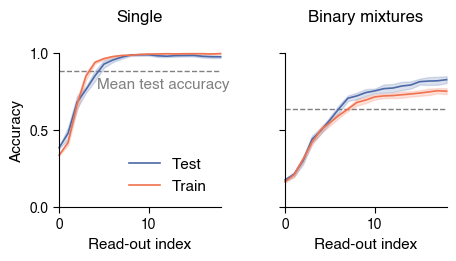

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(5, 2),
                       gridspec_kw={'wspace': 0.4},
                       sharey=True)

x_s = pos_s   # 0-indexed positions
x_m = pos_m

overall_test_s = all_acc_s_test.mean()
overall_test_m = all_acc_m_test.mean()

# --- Single gases ---
a = ax[0]
a.axhline(overall_test_s, color='gray', ls='--', lw=1, zorder=0)
a.plot(x_s, mean_acc_s_test, '-', color='C0', label='Test', clip_on=False)
a.fill_between(x_s, mean_acc_s_test - std_acc_s_test, mean_acc_s_test + std_acc_s_test,
               alpha=0.2, color='C0', clip_on=False)
a.plot(x_s, mean_acc_s_train, '-', color='C1', label='Train', clip_on=False)
a.fill_between(x_s, mean_acc_s_train - std_acc_s_train, mean_acc_s_train + std_acc_s_train,
               alpha=0.2, color='C1', clip_on=False)
a.set_xlabel('Read-out index', fontsize=11)
a.set_ylabel('Accuracy', fontsize=11)
a.set_title('Single', fontsize=12, y=1.15)
a.set_ylim(0, 1)
a.set_yticks([0, 0.5, 1])
a.set_xticks([0, 10, 20])
a.set_xlim(0, x_s.max())
a.spines['bottom'].set_bounds(0, x_s.max())
a.legend(loc='lower right', frameon=False, fontsize=11)
a.text(x_s.max() + 1., overall_test_s - 0.04, 'Mean test accuracy',
       color='gray', fontsize=11, ha='right', va='top')

# --- Binary mixtures ---
a = ax[1]
a.axhline(overall_test_m, color='gray', ls='--', lw=1, zorder=0)
a.plot(x_m, mean_acc_m_test, '-', color='C0', label='Test', clip_on=False)
a.fill_between(x_m, mean_acc_m_test - std_acc_m_test, mean_acc_m_test + std_acc_m_test,
               alpha=0.2, color='C0', clip_on=False)
a.plot(x_m, mean_acc_m_train, '-', color='C1', label='Train', clip_on=False)
a.fill_between(x_m, mean_acc_m_train - std_acc_m_train, mean_acc_m_train + std_acc_m_train,
               alpha=0.2, color='C1', clip_on=False)
a.set_xlabel('Read-out index', fontsize=11)
a.set_title('Binary mixtures', fontsize=12, y=1.15)
a.set_ylim(0, 1)
a.set_yticks([0, 0.5, 1])
a.set_xticks([0, 10, 20])
a.set_xlim(0, x_m.max())
a.spines['bottom'].set_bounds(0, x_m.max())
# a.text(x_m.max(), overall_test_m - 0.04, 'Avg. test accuracy',
#        color='gray', fontsize=11, ha='right', va='top')

os.makedirs('figs', exist_ok=True)
plt.savefig('figs/rapid_inference.pdf', bbox_inches='tight')
plt.show()

In [36]:
avg_s = all_acc_s_test.mean()
avg_m = all_acc_m_test.mean()
n_pos = max(len(pos_s), len(pos_m))

print(f"{'':>4s}  {'Single':>21s}             {'Binary mixtures':>21s}")
print(f"{'Pos':>4s}  {'Acc':>7s} {'± std':>7s}  {'> Avg?':>6s}     {'Acc':>7s} {'± std':>7s}  {'> Avg?':>6s}")
print(f"{'':>4s}  {'─'*23}     {'─'*23}")
for i in range(n_pos):
    row = f"{i:4d}  "
    if i < len(pos_s):
        above_s = mean_acc_s_test[i] > avg_s
        row += f"{mean_acc_s_test[i]:7.3f} {std_acc_s_test[i]:7.3f}  {'  yes' if above_s else '     '}"
    else:
        row += f"{'':>23s}"
    row += "     "
    if i < len(pos_m):
        above_m = mean_acc_m_test[i] > avg_m
        row += f"{mean_acc_m_test[i]:7.3f} {std_acc_m_test[i]:7.3f}  {'  yes' if above_m else '     '}"
    print(row)

print(f"\n{'Avg':>4s}  {avg_s:7.3f}{'':>23s}{avg_m:7.3f}")

above_pos_s = pos_s[mean_acc_s_test > avg_s]
above_pos_m = pos_m[mean_acc_m_test > avg_m]
print(f"\nSingle:  above average from position {above_pos_s[0]} ({len(above_pos_s)}/{len(pos_s)} positions)")
print(f"Binary:  above average from position {above_pos_m[0]} ({len(above_pos_m)}/{len(pos_m)} positions)")

                     Single                   Binary mixtures
 Pos      Acc   ± std  > Avg?         Acc   ± std  > Avg?
      ───────────────────────     ───────────────────────
   0    0.385   0.005              0.176   0.008       
   1    0.479   0.040              0.213   0.014       
   2    0.680   0.040              0.301   0.025       
   3    0.763   0.020              0.440   0.024       
   4    0.852   0.034              0.496   0.020       
   5    0.928   0.023    yes       0.566   0.020       
   6    0.955   0.014    yes       0.638   0.024       
   7    0.973   0.010    yes       0.706   0.018    yes
   8    0.987   0.006    yes       0.722   0.021    yes
   9    0.989   0.007    yes       0.743   0.022    yes
  10    0.989   0.006    yes       0.754   0.015    yes
  11    0.982   0.007    yes       0.769   0.027    yes
  12    0.979   0.006    yes       0.773   0.027    yes
  13    0.983   0.007    yes       0.786   0.027    yes
  14    0.984   0.006    yes       0.7